Install and Upload Library

In [134]:
%pip install pandas numpy scipy scikit-learn tensorflow xgboost matplotlib
import os
import numpy as np
import pandas as pd
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from collections import defaultdict
import warnings
import joblib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
    print("XGBoost is available")
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost is not available")

Note: you may need to restart the kernel to use updated packages.
XGBoost is available


In [135]:
#download data in folder work/data (SOLO SE SEI SU SSPCLOUD)
#!../sspcloud/download_data_all.sh

SET parameters and DATA UTILITY FUNCTIONS

In [ ]:
# Seed for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = str(SEED)

# Dynamic parameters
DYNAMIC_PARAMS = {
    'M': 10,           # Thousands of samples for TRAINING (10 = 10,000)
    'M_test': 2,       # Thousands of samples for UNSEEN TEST (2 = 2,000)
    'TH': 20,          # Threshold (optional)
    'NOISE_X': 40,     # Percentage of randomness
}

# Paths for Windows
base_path = r"G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat"
#base_path = rf"/home/onyxia/work/data/"
step1_dir = os.path.join(base_path, "Step1", "output")
step2_dir = os.path.join(base_path, "Step2", "output")
models_dir = os.path.join(base_path, "Step3", "Output", "output_keras")
reports_dir = os.path.join(base_path, "Step3", "Output", "reports")
plots_dir = os.path.join(base_path, "Step3", "Output", "Plots")

# Create directories
os.makedirs(models_dir, exist_ok=True)
os.makedirs(reports_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

print(f"Step1: {step1_dir}")
print(f"Step2: {step2_dir}")
print(f"Models: {models_dir}")
print(f"Reports: {reports_dir}")
print(f"Plots: {plots_dir}")

# Column configuration
selected_columns = [
    'age',
    'municipality_residence',
    'civil_status',
    'gender',
    'occupation',
    'physical_activity',
    'genetic_predisposition',
    'diagnosis'
]

one_hot_columns = [
    'gender',
    'civil_status',
    'municipality_residence',
    'physical_activity',
    'genetic_predisposition',
    'age',
    'occupation'
]

# Model architecture
MLP_HIDDEN_LAYERS = [256, 128, 64, 32]
MLP_OUTPUT_SIZE = 4

# Training parameters
TRAINING_PARAMS = {
    'test_size': 0.2,
    'epochs': 30,
    'batch_size': 32,
    'learning_rate': 0.001,
    'early_stopping_patience': 15,
    'early_stopping_min_delta': 0.001
}

# Model hyperparameters
RF_PARAMS = {
    'n_estimators': 200,
    'random_state': SEED,
    'class_weight': 'balanced',
    'n_jobs': -1
}

XGB_PARAMS = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'objective': 'multi:softmax',
    'num_class': 4,
    'random_state': SEED,  
    'use_label_encoder': False,
    'eval_metric': 'mlogloss',
    'n_jobs': 1,
    'verbosity': 0,  
    'tree_method': 'exact' 
}

LR_PARAMS = {
    'max_iter': 2000,
    'random_state': SEED,
    'class_weight': 'balanced',
    'n_jobs': -1
}


def preprocess_dataset(file_path):
    """Preprocess a dataset by selecting columns and applying one-hot encoding."""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File does not exist: {file_path}")
    
    df = pd.read_csv(file_path)
    df_filtered = df[selected_columns]
    df_encoded = pd.get_dummies(df_filtered, columns=one_hot_columns, drop_first=False)
    
    X = df_encoded.drop("diagnosis", axis=1)
    y = df_encoded["diagnosis"].values.ravel()
    
    return X, y

def align_datasets(synth_data, real_columns):
    """Align synthetic dataset to real dataset columns."""
    if isinstance(synth_data, dict):
        first_key = list(synth_data.keys())[0]
        synth_data = synth_data[first_key]
    
    synth_df = synth_data.copy()
    
    for col in real_columns:
        if col not in synth_df.columns:
            synth_df[col] = 0
    
    for col in synth_df.columns:
        if col not in real_columns:
            synth_df = synth_df.drop(columns=[col])
    
    return synth_df[real_columns]

def align_to_mlp_features(mlp_model_path, X_data, dataset_name=""):
    """Align data to MLP expected features."""
    try:
        model = load_model(mlp_model_path)
        expected_features = model.input_shape[1]
        
        if isinstance(X_data, dict):
            X_data = X_data[list(X_data.keys())[0]]
        
        if not isinstance(X_data, pd.DataFrame):
            X_data = pd.DataFrame(X_data)
        
        if X_data.shape[1] == expected_features:
            return X_data, X_data.columns.tolist()
        
        if X_data.shape[1] > expected_features:
            aligned_cols = X_data.columns.tolist()[:expected_features]
        else:
            aligned_cols = X_data.columns.tolist()
            for i in range(expected_features - len(aligned_cols)):
                aligned_cols.append(f"extra_col_{i}")
        
        X_aligned = X_data[aligned_cols].copy()
        print(f"{dataset_name}: {X_data.shape[1]} -> {X_aligned.shape[1]} features")
        
        return X_aligned, aligned_cols
        
    except Exception as e:
        print(f"Alignment error {dataset_name}: {e}")
        return X_data, X_data.columns.tolist() if hasattr(X_data, 'columns') else []

def align_df_to_mlp_features(df, mlp_features):
    """Align DataFrame to MLP features."""
    if not isinstance(df, pd.DataFrame):
        if hasattr(df, 'columns'):
            df = pd.DataFrame(df, columns=df.columns)
        else:
            if len(mlp_features) == df.shape[1]:
                return pd.DataFrame(df, columns=mlp_features)
            else:
                return df
    
    df_aligned = df.copy()
    
    for col in mlp_features:
        if col not in df_aligned.columns:
            df_aligned[col] = 0
    
    extra_cols = [col for col in df_aligned.columns if col not in mlp_features]
    if extra_cols:
        df_aligned = df_aligned.drop(columns=extra_cols)
    
    return df_aligned[mlp_features]

def remove_X2_features(dataset):
    """Remove X2 features (physical_activity and genetic_predisposition)."""
    if isinstance(dataset, dict):
        dataset = dataset[list(dataset.keys())[0]]
    
    dataset_mod = dataset.copy()
    
    pa_cols = [col for col in dataset_mod.columns if col.startswith('physical_activity_')]
    gp_cols = [col for col in dataset_mod.columns if col.startswith('genetic_predisposition_')]
    
    for col in pa_cols + gp_cols:
        if col in dataset_mod.columns:
            dataset_mod[col] = 0
    
    if 'physical_activity_Missing' in dataset_mod.columns:
        dataset_mod['physical_activity_Missing'] = 1
    if 'genetic_predisposition_Missing' in dataset_mod.columns:
        dataset_mod['genetic_predisposition_Missing'] = 1
    
    return dataset_mod

def apply_sampling(X, y, M_k):
    """Nessun sampling per M=10 - mantiene tutti i 10000 samples"""
    if M_k == 10:
        return X, y
    try:
        desired = int(M_k) * 1000
        if 0 < desired < len(y):
            X_sample, _, y_sample, _ = train_test_split(
                X, y, train_size=desired, random_state=SEED, stratify=y
            )
            return X_sample, y_sample
    except Exception as e:
        print(f"Sampling error: {e}")
    return X, y

Step1: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step1\output
Step2: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step2\output
Models: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step3\Output\output_keras
Reports: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step3\Output\reports
Plots: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step3\Output\Plots


MODEL UTILITY FUNCTIONS

In [137]:
def get_model_filename(cfg, model_type, model_suffix=""):
    """Generate filename for different model types."""
    name = cfg["name"]
    synth_type = cfg.get("synth_type", "")
    synth_version = cfg.get("synth_version", "")
    
    if cfg["type"] == "real":
        base_name = f"REAL_{cfg.get('noise_scenario', 'RN0')}"
    else:
        if synth_type and synth_version:
            base_name = f"SYNTHETIC_{synth_type.upper()}_{synth_version}"
        elif synth_type:
            base_name = f"SYNTHETIC_{synth_type.upper()}"
        else:
            base_name = "SYNTHETIC"
    
    noise_suffix = f"_NOISE{DYNAMIC_PARAMS['NOISE_X']}" if "random" in name.lower() else ""
    
    if model_type == "mlp":
        return f"mlp_{base_name}_M{DYNAMIC_PARAMS['M']}_TH{DYNAMIC_PARAMS['TH']}{noise_suffix}{model_suffix}.keras"
    elif model_type == "lr":
        return f"lr_{base_name}_M{DYNAMIC_PARAMS['M']}_TH{DYNAMIC_PARAMS['TH']}{noise_suffix}{model_suffix}.pkl"
    elif model_type == "rf":
        return f"rf_{base_name}_M{DYNAMIC_PARAMS['M']}_TH{DYNAMIC_PARAMS['TH']}{noise_suffix}{model_suffix}.pkl"
    elif model_type == "xgb":
        return f"xgb_{base_name}_M{DYNAMIC_PARAMS['M']}_TH{DYNAMIC_PARAMS['TH']}{noise_suffix}{model_suffix}.pkl"
    else:
        return f"{model_type}_{base_name}_M{DYNAMIC_PARAMS['M']}_TH{DYNAMIC_PARAMS['TH']}{noise_suffix}{model_suffix}.pkl"
    
def create_mlp_model_4hl(input_dim):
    """Create MLP with 4 hidden layers."""
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(MLP_HIDDEN_LAYERS[0], activation='relu'),
        Dense(MLP_HIDDEN_LAYERS[1], activation='relu'),
        Dense(MLP_HIDDEN_LAYERS[2], activation='relu'),
        Dense(MLP_HIDDEN_LAYERS[3], activation='relu'),
        Dense(MLP_OUTPUT_SIZE, activation='softmax')
    ])
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=TRAINING_PARAMS['learning_rate']),
        loss='categorical_crossentropy',
        metrics=['accuracy', 'precision', 'recall', 'auc']
    )
    
    return model

def train_mlp_model(cfg):
    """Train MLP model for a single configuration."""
    name = cfg["name"]
    mlp_path = cfg["mlp_path"]
    
    print(f"\n[{name}] Training MLP...")
    
    if "X_train_aligned" not in cfg or "y_train" not in cfg:
        print("  ✗ Skipped - incomplete configuration")
        return False
    
    if os.path.exists(mlp_path):
        print("  ✓ Model already exists, skipped")
        return False
    
    try:
        X_data = cfg["X_train_aligned"].astype(np.float32)
        y_data = to_categorical(cfg["y_train"] - 1, num_classes=4)
        
        X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
            X_data, y_data, 
            test_size=TRAINING_PARAMS['test_size'], 
            random_state=SEED, 
            stratify=cfg["y_train"]
        )
        
        model = create_mlp_model_4hl(X_data.shape[1])
        
        callbacks = [
            ModelCheckpoint(mlp_path, monitor='val_accuracy', save_best_only=True, mode='max', verbose=0),
            EarlyStopping(monitor='val_accuracy', patience=TRAINING_PARAMS['early_stopping_patience'],
                         min_delta=TRAINING_PARAMS['early_stopping_min_delta'], 
                         mode='max', restore_best_weights=True, verbose=0)
        ]
        
        history = model.fit(
            X_train_split, y_train_split,
            epochs=TRAINING_PARAMS['epochs'],
            batch_size=TRAINING_PARAMS['batch_size'],
            validation_data=(X_val_split, y_val_split),
            verbose=0,
            callbacks=callbacks
        )
        
        model.save(mlp_path.replace('.keras', '_final.keras'))
        
        history_df = pd.DataFrame(history.history)
        history_df['epoch'] = range(1, len(history_df) + 1)
        history_df.to_csv(mlp_path.replace('.keras', '_history.csv'), index=False, sep=';')
        
        val_acc = max(history.history['val_accuracy'])
        print(f"  ✓ Completed - Val accuracy: {val_acc:.4f}")
        return True
        
    except Exception as e:
        print(f"  ✗ Error: {e}")
        return False

def train_lr_model(cfg):
    """Train Logistic Regression model."""
    try:
        model = LogisticRegression(**LR_PARAMS)
        model.fit(cfg["X_train_aligned"], cfg["y_train"])
        joblib.dump(model, cfg["lr_path"])
        print(f"  ✓ Logistic Regression saved")
        return True
    except Exception as e:
        print(f"  ✗ LR error: {e}")
        return False

def train_rf_model(cfg):
    """Train Random Forest model."""
    try:
        model = RandomForestClassifier(**RF_PARAMS)
        model.fit(cfg["X_train_aligned"], cfg["y_train"])
        joblib.dump(model, cfg["rf_path"])
        print(f"  ✓ Random Forest saved")
        return True
    except Exception as e:
        print(f"  ✗ RF error: {e}")
        return False

def train_xgb_model(cfg):
    """Train XGBoost model."""
    if not XGBOOST_AVAILABLE:
        return False
    try:
        model = xgb.XGBClassifier(**XGB_PARAMS)
        model.fit(cfg["X_train_aligned"], cfg["y_train"] - 1)
        joblib.dump(model, cfg["xgb_path"])
        print(f"  ✓ XGBoost saved")
        return True
    except Exception as e:
        print(f"  ✗ XGB error: {e}")
        return False

def calculate_mlp_params(input_dim):
    """Calculate MLP parameters."""
    layers = [input_dim] + MLP_HIDDEN_LAYERS + [MLP_OUTPUT_SIZE]
    total_params = 0
    for i in range(len(layers)-1):
        total_params += (layers[i] * layers[i+1]) + layers[i+1]
    return total_params

LOAD REAL DATASETS (M10 for TRAINING - 10000 samples)

In [138]:
print("="*60)
print("LOADING REAL DATASETS (M10 for TRAINING - 10000 samples)")
print("="*60)

X_train_real = {}
y_train_real = {}

# RN0 - senza rumore
file_path_rn0 = os.path.join(step1_dir, "real_data_datasetM10_TH20_RN_PR0_4CAT_MISS_X2.csv")
if os.path.exists(file_path_rn0):
    X, y = preprocess_dataset(file_path_rn0)
    X_train_real["RN0"] = X
    y_train_real["RN0"] = y
    print(f"✓ Loaded RN0 (M10): {X.shape} samples")
else:
    print(f"✗ File not found: {file_path_rn0}")

# RY40 - con rumore 40%
file_path_ry40 = os.path.join(step1_dir, "real_data_datasetM10_TH20_RY_PR40_4CAT_MISS_X2.csv")
if os.path.exists(file_path_ry40):
    X, y = preprocess_dataset(file_path_ry40)
    X_train_real["RY40"] = X
    y_train_real["RY40"] = y
    print(f"✓ Loaded RY40 (M10): {X.shape} samples")
else:
    print(f"✗ File not found: {file_path_ry40}")

LOADING REAL DATASETS (M10 for TRAINING - 10000 samples)
✓ Loaded RN0 (M10): (10000, 217) samples
✓ Loaded RY40 (M10): (10000, 217) samples


LOAD SYNTHETIC DATASETS (M10 for TRAINING - 10000 samples)

In [139]:
print("\n" + "="*60)
print("LOADING SYNTHETIC DATASETS (M10 for TRAINING - 10000 samples)")
print("="*60)

synthetic_configs = {
    "SN0_ctgan": {"R": "N", "PR": 0, "tipo": "CTGAN"},
    "SN0_tvae": {"R": "N", "PR": 0, "tipo": "TVAE"},
    "SN0_xgboost_O0": {"R": "N", "PR": 0, "tipo": "XGBoost_O0"},
    "SY40_ctgan": {"R": "Y", "PR": 40, "tipo": "CTGAN"},
    "SY40_tvae": {"R": "Y", "PR": 40, "tipo": "TVAE"},
    "SY40_xgboost_O0": {"R": "Y", "PR": 40, "tipo": "XGBoost_O0"}
}

X_train_synth = {}
y_train_synth = {}

for key, params in synthetic_configs.items():
    file_path = os.path.join(
        step2_dir,
        f'synthetic_data_datasetM10_TH20_R{params["R"]}_PR{params["PR"]}_4CAT_MISS_X2_{params["tipo"]}.csv'
    )
    
    if os.path.exists(file_path):
        X, y = preprocess_dataset(file_path)
        X_train_synth[key] = X
        y_train_synth[key] = y
        print(f"✓ Loaded {key} (M10): {X.shape} samples")
    else:
        print(f"✗ File not found: {key}")

print("\n" + "="*60)
print("ALIGNING SYNTHETIC DATASETS (M10)")
print("="*60)

real_columns = X_train_real["RN0"].columns.tolist()
print(f"Reference columns from RN0: {len(real_columns)}")

X_train_synth_aligned = {}
for key in X_train_synth.keys():
    X_train_synth_aligned[key] = align_datasets(X_train_synth[key], real_columns)
    print(f"✓ {key}: {X_train_synth[key].shape[1]} -> {X_train_synth_aligned[key].shape[1]} columns")


LOADING SYNTHETIC DATASETS (M10 for TRAINING - 10000 samples)
✓ Loaded SN0_ctgan (M10): (10000, 217) samples
✓ Loaded SN0_tvae (M10): (10000, 189) samples
✓ Loaded SN0_xgboost_O0 (M10): (10000, 216) samples
✓ Loaded SY40_ctgan (M10): (10000, 217) samples
✓ Loaded SY40_tvae (M10): (10000, 197) samples
✓ Loaded SY40_xgboost_O0 (M10): (10000, 216) samples

ALIGNING SYNTHETIC DATASETS (M10)
Reference columns from RN0: 217
✓ SN0_ctgan: 217 -> 217 columns
✓ SN0_tvae: 189 -> 217 columns
✓ SN0_xgboost_O0: 216 -> 217 columns
✓ SY40_ctgan: 217 -> 217 columns
✓ SY40_tvae: 197 -> 217 columns
✓ SY40_xgboost_O0: 216 -> 217 columns


LOAD UNSEEN TEST DATASET 

In [140]:
print("\n" + "="*60)
print("LOADING UNSEEN TEST DATASETS (REAL M2 - INDIPENDENTE - 2000 samples)")
print("="*60)

# M2 senza rumore (per testare modelli RN0)
test_path_rn0 = os.path.join(step1_dir, f'real_data_datasetM{DYNAMIC_PARAMS["M_test"]}_TH20_RN_PR0_4CAT_MISS_X2.csv')
X_test_unseen_RN0, y_test_unseen_RN0 = preprocess_dataset(test_path_rn0)
print(f"✓ Loaded test RN0 (M2): {X_test_unseen_RN0.shape}")

# M2 con rumore 40% (per testare modelli RY40)
test_path_ry40 = os.path.join(step1_dir, f'real_data_datasetM{DYNAMIC_PARAMS["M_test"]}_TH20_RY_PR40_4CAT_MISS_X2.csv')
X_test_unseen_RY40, y_test_unseen_RY40 = preprocess_dataset(test_path_ry40)
print(f"✓ Loaded test RY40 (M2): {X_test_unseen_RY40.shape}")


LOADING UNSEEN TEST DATASETS (REAL M2 - INDIPENDENTE - 2000 samples)
✓ Loaded test RN0 (M2): (2000, 211)
✓ Loaded test RY40 (M2): (2000, 211)


Model Configuration

In [141]:
print("\n" + "="*60)
print("CREATING MODEL CONFIGURATIONS")
print("="*60)

configs = []

# REAL - senza rumore (RN0)
cfg = {
    "name": "Real (RN0)",
    "type": "real",
    "train_key": "RN0",
    "noise_scenario": "RN0",
    "X_train": X_train_real["RN0"],
    "y_train": y_train_real["RN0"],
}
for mt in ["mlp", "lr", "rf", "xgb"]:
    cfg[f"{mt}_path"] = os.path.join(models_dir, get_model_filename(cfg, mt))
configs.append(cfg)
print(f"✓ Added real: Real (RN0)")

# REAL - con rumore 40% (RY40)
cfg = {
    "name": "Real (RY40)",
    "type": "real",
    "train_key": "RY40",
    "noise_scenario": "RY40",
    "X_train": X_train_real["RY40"],
    "y_train": y_train_real["RY40"],
}
for mt in ["mlp", "lr", "rf", "xgb"]:
    cfg[f"{mt}_path"] = os.path.join(models_dir, get_model_filename(cfg, mt))
configs.append(cfg)
print(f"✓ Added real: Real (RY40)")

# SYNTHETIC - senza rumore
for synth_key in ["SN0_ctgan", "SN0_tvae", "SN0_xgboost_O0"]:
    if synth_key in X_train_synth_aligned:
        parts = synth_key.split("_")
        model_name = synth_key.replace("SN0_", "").replace("_", " ").upper()
        cfg = {
            "name": f"Synthetic ({model_name})",
            "type": "synthetic",
            "train_key": synth_key,
            "synth_type": parts[1],
            "synth_version": parts[2] if len(parts) > 2 else "",
            "X_train": X_train_synth_aligned[synth_key],
            "y_train": y_train_synth[synth_key],
        }
        for mt in ["mlp", "lr", "rf", "xgb"]:
            cfg[f"{mt}_path"] = os.path.join(models_dir, get_model_filename(cfg, mt))
        configs.append(cfg)
        print(f"✓ Added synthetic: Synthetic ({model_name})")

# SYNTHETIC - con rumore 40%
for synth_key in ["SY40_ctgan", "SY40_tvae", "SY40_xgboost_O0"]:
    if synth_key in X_train_synth_aligned:
        parts = synth_key.split("_")
        model_name = synth_key.replace("SY40_", "").replace("_", " ").upper()
        cfg = {
            "name": f"Synthetic ({model_name}) - 40% random",
            "type": "synthetic",
            "train_key": synth_key,
            "synth_type": parts[1],
            "synth_version": parts[2] if len(parts) > 2 else "",
            "X_train": X_train_synth_aligned[synth_key],
            "y_train": y_train_synth[synth_key],
        }
        for mt in ["mlp", "lr", "rf", "xgb"]:
            cfg[f"{mt}_path"] = os.path.join(models_dir, get_model_filename(cfg, mt))
        configs.append(cfg)
        print(f"✓ Added synthetic: Synthetic ({model_name}) - 40% random")

print(f"\nTotal configurations: {len(configs)}")


CREATING MODEL CONFIGURATIONS
✓ Added real: Real (RN0)
✓ Added real: Real (RY40)
✓ Added synthetic: Synthetic (CTGAN)
✓ Added synthetic: Synthetic (TVAE)
✓ Added synthetic: Synthetic (XGBOOST O0)
✓ Added synthetic: Synthetic (CTGAN) - 40% random
✓ Added synthetic: Synthetic (TVAE) - 40% random
✓ Added synthetic: Synthetic (XGBOOST O0) - 40% random

Total configurations: 8


FEATURE ALIGNMENT FOR MLP

In [142]:
print("="*60)
print("FEATURE ALIGNMENT FOR MLP")
print("="*60)

for cfg in configs:
    if os.path.exists(cfg["mlp_path"]):
        cfg["X_train_aligned"], cfg["mlp_features"] = align_to_mlp_features(
            cfg["mlp_path"], cfg["X_train"], f"Train {cfg['name']}"
        )
        print(f"✓ {cfg['name']}: {cfg['X_train_aligned'].shape[1]} features (aligned to existing MLP)")
    else:
        cfg["X_train_aligned"] = cfg["X_train"]
        cfg["mlp_features"] = cfg["X_train"].columns.tolist()
        print(f"✓ {cfg['name']}: {len(cfg['mlp_features'])} features (new model)")

print("\n" + "="*60)
print("APPLYING SAMPLING")
print("="*60)

for cfg in configs:
    cfg["X_train_aligned"], cfg["y_train"] = apply_sampling(
        cfg["X_train_aligned"], cfg["y_train"], DYNAMIC_PARAMS['M']
    )
    print(f"✓ {cfg['name']}: {cfg['X_train_aligned'].shape[0]} training samples")

print("\n" + "="*60)
print("ALIGNING UNSEEN TEST DATA FOR EACH MODEL")
print("="*60)

for cfg in configs:
    if "random" in cfg["name"].lower() or "RY40" in cfg["name"]:
        X_test_raw = X_test_unseen_RY40
        y_test_raw = y_test_unseen_RY40
        scenario = "RY40"
    else:
        X_test_raw = X_test_unseen_RN0
        y_test_raw = y_test_unseen_RN0
        scenario = "RN0"

    cfg["X_test_unseen_aligned"] = align_df_to_mlp_features(X_test_raw, cfg["mlp_features"])
    cfg["y_test_unseen"] = y_test_raw
    print(f"✓ {cfg['name']}: test aligned to {cfg['X_test_unseen_aligned'].shape[1]} features [{scenario}]")

FEATURE ALIGNMENT FOR MLP
✓ Real (RN0): 217 features (aligned to existing MLP)
✓ Real (RY40): 217 features (aligned to existing MLP)
✓ Synthetic (CTGAN): 217 features (aligned to existing MLP)
✓ Synthetic (TVAE): 217 features (aligned to existing MLP)
✓ Synthetic (XGBOOST O0): 217 features (aligned to existing MLP)
✓ Synthetic (CTGAN) - 40% random: 217 features (aligned to existing MLP)
✓ Synthetic (TVAE) - 40% random: 217 features (aligned to existing MLP)
✓ Synthetic (XGBOOST O0) - 40% random: 217 features (aligned to existing MLP)

APPLYING SAMPLING
✓ Real (RN0): 10000 training samples
✓ Real (RY40): 10000 training samples
✓ Synthetic (CTGAN): 10000 training samples
✓ Synthetic (TVAE): 10000 training samples
✓ Synthetic (XGBOOST O0): 10000 training samples
✓ Synthetic (CTGAN) - 40% random: 10000 training samples
✓ Synthetic (TVAE) - 40% random: 10000 training samples
✓ Synthetic (XGBOOST O0) - 40% random: 10000 training samples

ALIGNING UNSEEN TEST DATA FOR EACH MODEL
✓ Real (RN0):

TRAIN MODELS

In [143]:
train_models = input("\nTrain missing models? (y/n): ").lower() == 'y'

if train_models:
    print("\n" + "="*60)
    print("TRAINING MODELS")
    print("="*60)
    
    for model_type in ["mlp", "lr", "rf", "xgb"]:
        if model_type == "xgb" and not XGBOOST_AVAILABLE:
            continue
            
        print(f"\n{'-'*50}")
        print(f"TRAINING {model_type.upper()} MODELS")
        print(f"{'-'*50}")
        
        trained = 0
        skipped = 0
        
        for cfg in configs:
            if os.path.exists(cfg[f"{model_type}_path"]):
                skipped += 1
                continue
            
            if model_type == "mlp":
                success = train_mlp_model(cfg)
            elif model_type == "lr":
                success = train_lr_model(cfg)
            elif model_type == "rf":
                success = train_rf_model(cfg)
            elif model_type == "xgb":
                success = train_xgb_model(cfg)
            
            if success:
                trained += 1
        
        print(f"\n{model_type.upper()} Summary: Trained {trained}, Skipped {skipped}")


TRAINING MODELS

--------------------------------------------------
TRAINING MLP MODELS
--------------------------------------------------

MLP Summary: Trained 0, Skipped 8

--------------------------------------------------
TRAINING LR MODELS
--------------------------------------------------

LR Summary: Trained 0, Skipped 8

--------------------------------------------------
TRAINING RF MODELS
--------------------------------------------------

RF Summary: Trained 0, Skipped 8

--------------------------------------------------
TRAINING XGB MODELS
--------------------------------------------------

XGB Summary: Trained 0, Skipped 8


EVALUATION: TRAIN ACCURACY (su M10) vs TEST ACCURACY (su M2)

In [144]:
print("\n" + "="*60)
print("ALIGNING REAL M10 FOR TRAIN EVALUATION (TSTR)")
print("="*60)

for cfg in configs:
    if "random" in cfg["name"].lower() or "RY40" in cfg["name"]:
        cfg["X_eval_real"] = align_df_to_mlp_features(X_train_real["RY40"], cfg["mlp_features"])
        cfg["y_eval_real"] = y_train_real["RY40"]
        scenario = "RY40"
    else:
        cfg["X_eval_real"] = align_df_to_mlp_features(X_train_real["RN0"], cfg["mlp_features"])
        cfg["y_eval_real"] = y_train_real["RN0"]
        scenario = "RN0"
    print(f"✓ {cfg['name']}: eval real aligned [{scenario}]")

print("\n" + "="*60)
print(" ACCURACY TRAINING AND TEST")
print("="*60)

all_results = []

for cfg in configs:
    model_name = cfg["name"]
    
    X_train_eval = cfg["X_eval_real"]
    y_train_eval = cfg["y_eval_real"]
    X_test_eval = cfg["X_test_unseen_aligned"]
    y_test_eval = cfg["y_test_unseen"]  
    
    results = {"Model": model_name}
    
    print(f"\n{model_name}:")
    
    # MLP
    if os.path.exists(cfg["mlp_path"]):
        try:
            model = load_model(cfg["mlp_path"])
            y_train_pred = np.argmax(model.predict(X_train_eval.values.astype(np.float32), verbose=0), axis=1)
            train_acc = accuracy_score(y_train_eval - 1, y_train_pred)
            y_test_pred = np.argmax(model.predict(X_test_eval.values.astype(np.float32), verbose=0), axis=1)
            test_acc = accuracy_score(y_test_eval - 1, y_test_pred)
            results["MLP_train"] = train_acc
            results["MLP_test"] = test_acc
            print(f"  MLP  - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")
        except Exception as e:
            results["MLP_train"] = np.nan
            results["MLP_test"] = np.nan
            print(f"  MLP  - Error: {e}")
    else:
        results["MLP_train"] = np.nan
        results["MLP_test"] = np.nan
        print(f"  MLP  - Model not found")
    
    # Logistic Regression
    if os.path.exists(cfg["lr_path"]):
        try:
            model = joblib.load(cfg["lr_path"])
            train_acc = accuracy_score(y_train_eval, model.predict(X_train_eval))
            test_acc = accuracy_score(y_test_eval, model.predict(X_test_eval))
            results["LR_train"] = train_acc
            results["LR_test"] = test_acc
            print(f"  LR   - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")
        except Exception as e:
            results["LR_train"] = np.nan
            results["LR_test"] = np.nan
    else:
        results["LR_train"] = np.nan
        results["LR_test"] = np.nan
    
    # Random Forest
    if os.path.exists(cfg["rf_path"]):
        try:
            model = joblib.load(cfg["rf_path"])
            train_acc = accuracy_score(y_train_eval, model.predict(X_train_eval))
            test_acc = accuracy_score(y_test_eval, model.predict(X_test_eval))
            results["RF_train"] = train_acc
            results["RF_test"] = test_acc
            print(f"  RF   - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")
        except Exception as e:
            results["RF_train"] = np.nan
            results["RF_test"] = np.nan
    else:
        results["RF_train"] = np.nan
        results["RF_test"] = np.nan
    
    # XGBoost
    if XGBOOST_AVAILABLE and os.path.exists(cfg["xgb_path"]):
        try:
            model = joblib.load(cfg["xgb_path"])
            train_acc = accuracy_score(y_train_eval - 1, model.predict(X_train_eval))
            test_acc = accuracy_score(y_test_eval - 1, model.predict(X_test_eval))
            results["XGB_train"] = train_acc
            results["XGB_test"] = test_acc
            print(f"  XGB  - Train: {train_acc:.4f}, Test: {test_acc:.4f}, Gap: {train_acc - test_acc:.4f}")
        except Exception as e:
            results["XGB_train"] = np.nan
            results["XGB_test"] = np.nan
    else:
        results["XGB_train"] = np.nan
        results["XGB_test"] = np.nan
    
    all_results.append(results)

results_df = pd.DataFrame(all_results)
results_csv = os.path.join(reports_dir, "training_test_accuracy.csv")
results_df.to_csv(results_csv, index=False, sep=';')


ALIGNING REAL M10 FOR TRAIN EVALUATION (TSTR)
✓ Real (RN0): eval real aligned [RN0]
✓ Real (RY40): eval real aligned [RY40]
✓ Synthetic (CTGAN): eval real aligned [RN0]
✓ Synthetic (TVAE): eval real aligned [RN0]
✓ Synthetic (XGBOOST O0): eval real aligned [RN0]
✓ Synthetic (CTGAN) - 40% random: eval real aligned [RY40]
✓ Synthetic (TVAE) - 40% random: eval real aligned [RY40]
✓ Synthetic (XGBOOST O0) - 40% random: eval real aligned [RY40]

 ACCURACY TRAINING AND TEST

Real (RN0):
  MLP  - Train: 1.0000, Test: 0.9865, Gap: 0.0135
  LR   - Train: 0.9988, Test: 0.9860, Gap: 0.0128
  RF   - Train: 1.0000, Test: 0.9865, Gap: 0.0135
  XGB  - Train: 0.9974, Test: 0.9840, Gap: 0.0134

Real (RY40):
  MLP  - Train: 0.5916, Test: 0.5580, Gap: 0.0336
  LR   - Train: 0.5707, Test: 0.5445, Gap: 0.0262
  RF   - Train: 0.9939, Test: 0.5475, Gap: 0.4464
  XGB  - Train: 0.5989, Test: 0.5520, Gap: 0.0469

Synthetic (CTGAN):
  MLP  - Train: 0.8527, Test: 0.8670, Gap: -0.0143
  LR   - Train: 0.8684, Test

PLOT: TRAIN vs TEST ACCURACY

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Grafico r=0 salvato in: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step3\Output\Plots


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


✅ Grafico r=0.4 salvato in: G:\Users\donatella.papa\OneDrive - ISTAT\WP_13_Istat_Eurostat\Step3\Output\Plots


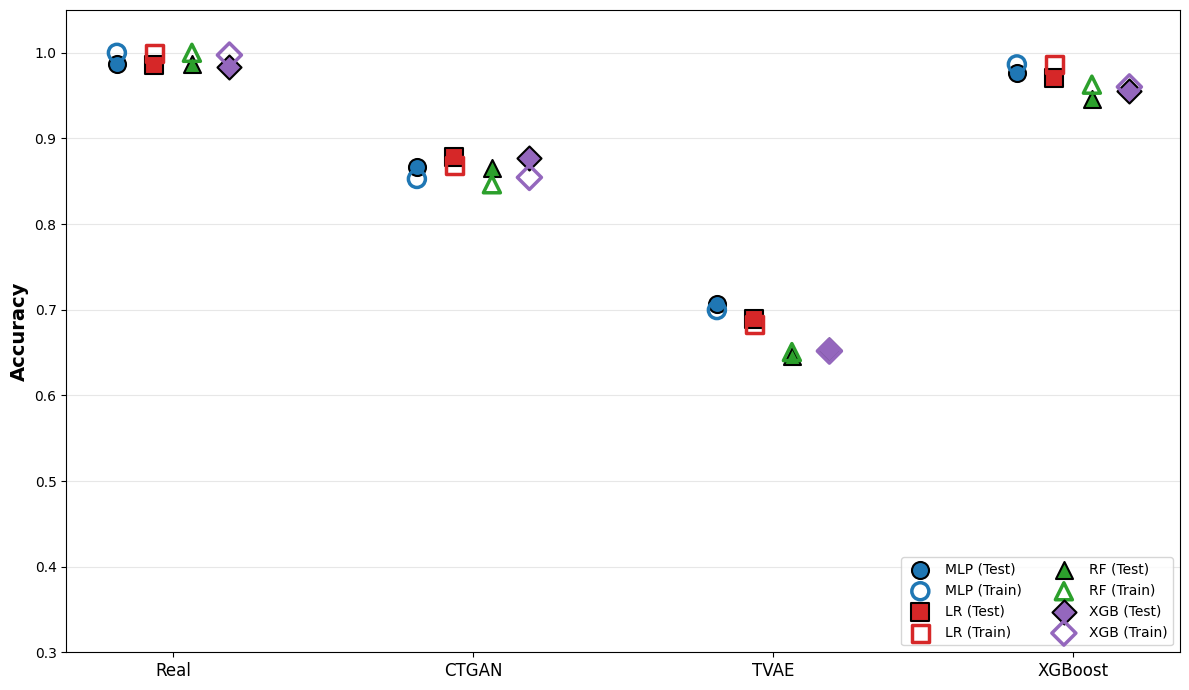

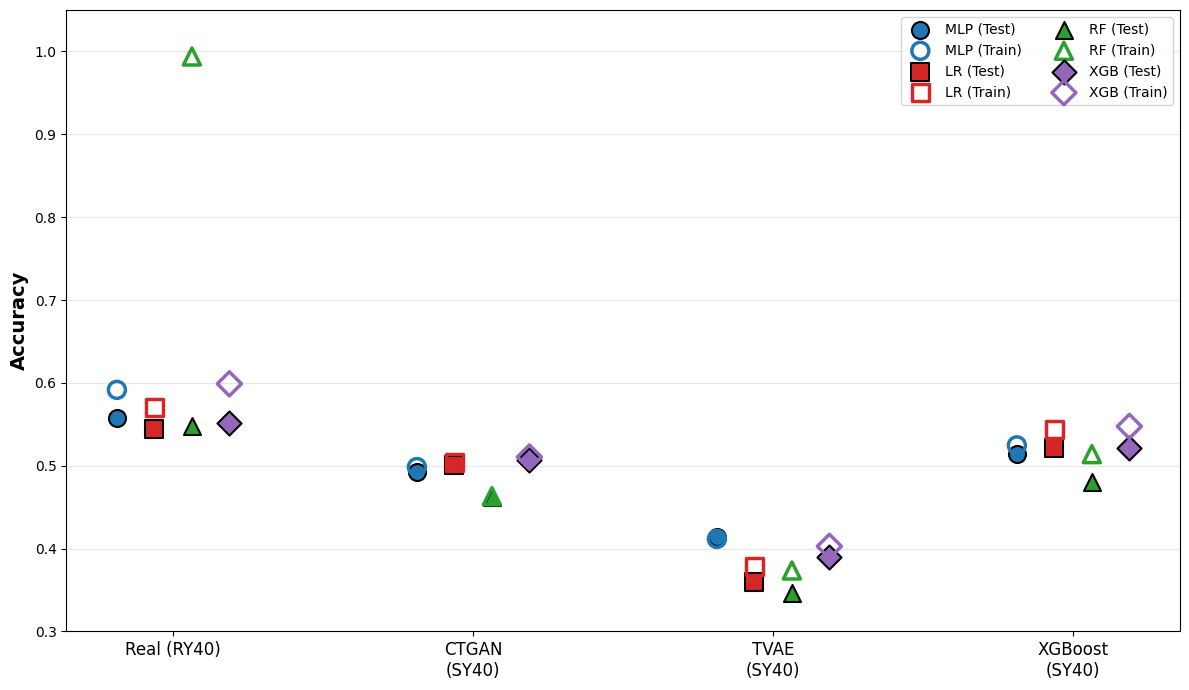

In [145]:
# r=0 
r0_models = [
    "Real (RN0)",
    "Synthetic (CTGAN)",
    "Synthetic (TVAE)",
    "Synthetic (XGBOOST O0)"
]

# r=0.4 
r04_models = [
    "Real (RY40)",
    "Synthetic (CTGAN) - 40% random",
    "Synthetic (TVAE) - 40% random",
    "Synthetic (XGBOOST O0) - 40% random"
]

classifiers = ['MLP', 'LR', 'RF', 'XGB']
markers = ['o', 's', '^', 'D']
colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

x = np.arange(len(r0_models))
offset = 0.25

# PRIMO GRAFICO: r = 0
fig1, ax1 = plt.subplots(figsize=(12, 7))

for i, (clf, color, marker) in enumerate(zip(classifiers, colors, markers)):
    x_positions = x + (i - 1.5) * (offset / 2)
    
    test_values = []
    train_values = []
    
    for model in r0_models:
        row = results_df[results_df['Model'] == model]
        if len(row) > 0:
            test_values.append(row[f'{clf}_test'].values[0])
            train_values.append(row[f'{clf}_train'].values[0])
        else:
            test_values.append(np.nan)
            train_values.append(np.nan)
    
    ax1.scatter(x_positions, test_values, 
                marker=marker, s=150, c=color, 
                edgecolor='black', linewidth=1.5, zorder=3, label=f'{clf} (Test)')
    
    ax1.scatter(x_positions, train_values, 
                marker=marker, s=150, facecolors='none', edgecolors=color, 
                linewidth=2.5, zorder=3, label=f'{clf} (Train)')

ax1.set_xticks(x)
ax1.set_xticklabels(['Real', 'CTGAN', 'TVAE', 'XGBoost'], fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax1.set_ylim(0.3, 1.05)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(loc='lower right', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'grafico_r0.jpg'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'grafico_r0.eps'), format='eps', bbox_inches='tight')
print(f"✅ Grafico r=0 salvato in: {plots_dir}")

# SECONDO GRAFICO: r = 0.4
fig2, ax2 = plt.subplots(figsize=(12, 7))

for i, (clf, color, marker) in enumerate(zip(classifiers, colors, markers)):
    x_positions = x + (i - 1.5) * (offset / 2)
    
    test_values = []
    train_values = []
    
    for model in r04_models:
        row = results_df[results_df['Model'] == model]
        if len(row) > 0:
            test_values.append(row[f'{clf}_test'].values[0])
            train_values.append(row[f'{clf}_train'].values[0])
        else:
            test_values.append(np.nan)
            train_values.append(np.nan)
    
    ax2.scatter(x_positions, test_values, 
                marker=marker, s=150, c=color, 
                edgecolor='black', linewidth=1.5, zorder=3, label=f'{clf} (Test)')
    
    ax2.scatter(x_positions, train_values, 
                marker=marker, s=150, facecolors='none', edgecolors=color, 
                linewidth=2.5, zorder=3, label=f'{clf} (Train)')

ax2.set_xticks(x)
ax2.set_xticklabels(['Real (RY40)', 'CTGAN\n(SY40)', 'TVAE\n(SY40)', 'XGBoost\n(SY40)'], fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax2.set_ylim(0.3, 1.05)
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend(loc='upper right', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(plots_dir, 'grafico_r04.jpg'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(plots_dir, 'grafico_r04.eps'), format='eps', bbox_inches='tight')
print(f"✅ Grafico r=0.4 salvato in: {plots_dir}")

plt.show()
